In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

DATA = Path.cwd() / 'data' / 'raw' / 'time_series_60min_singleindex.csv'
if not DATA.exists():
    DATA = Path.cwd().parent / 'data' / 'raw' / 'time_series_60min_singleindex.csv'
assert DATA.exists(), f'CSV not found: {DATA}'

columns = {
    'DE_load_actual_entsoe_transparency': 'load_mw',
    'DE_load_forecast_entsoe_transparency': 'published_forecast_mw',
    'DE_solar_generation_actual': 'solar_mw',
    'DE_wind_generation_actual': 'wind_mw',
    'DE_LU_price_day_ahead': 'price_eur_mwh',
}
df = pd.read_csv(DATA, usecols=['utc_timestamp', *columns], parse_dates=['utc_timestamp'])
df = df.rename(columns=columns).set_index('utc_timestamp').sort_index()
print(df.shape, df.index.min(), df.index.max())
display(df.head())

(50401, 5) 2014-12-31 23:00:00+00:00 2020-09-30 23:00:00+00:00


,load_mw,published_forecast_mw,solar_mw,wind_mw,price_eur_mwh
utc_timestamp,,,,,
2014-12-31 23:00:00+00:00,NaN,NaN,NaN,NaN,NaN
2015-01-01 00:00:00+00:00,41151.0,39723.0,NaN,8852.0,NaN
2015-01-01 01:00:00+00:00,40135.0,38813.0,NaN,9054.0,NaN
2015-01-01 02:00:00+00:00,39106.0,38490.0,NaN,9070.0,NaN
2015-01-01 03:00:00+00:00,38765.0,38644.0,NaN,9163.0,NaN


In [2]:
print('Duplicate timestamps:', df.index.duplicated().sum())
print('Expected hourly observations:', len(pd.date_range(df.index.min(), df.index.max(), freq='h')))
display(pd.DataFrame({'missing': df.isna().sum(), 'missing_pct': (100 * df.isna().mean()).round(2)}))
display(df[['load_mw', 'published_forecast_mw']].describe().round(1))
display(df.groupby(df.index.year)[['load_mw', 'published_forecast_mw', 'solar_mw', 'wind_mw', 'price_eur_mwh']].count())

Duplicate timestamps: 0
Expected hourly observations: 50401


,missing,missing_pct
load_mw,1,0.00
published_forecast_mw,25,0.05
solar_mw,104,0.21
wind_mw,75,0.15
price_eur_mwh,32861,65.20


,load_mw,published_forecast_mw
count,50400.0,50376.0
mean,55492.5,54791.4
std,10015.4,9496.9
min,31307.0,28824.0
25%,47106.0,46987.0
50%,55092.0,54731.5
75%,64309.2,62877.2
max,77549.0,75912.0


,load_mw,published_forecast_mw,solar_mw,wind_mw,price_eur_mwh
utc_timestamp,,,,,
2014,0,0,0,0,0
2015,8760,8760,8729,8760,0
2016,8784,8784,8712,8710,0
2017,8760,8760,8760,8760,0
2018,8760,8736,8760,8760,2209
2019,8760,8760,8760,8760,8758
2020,6576,6576,6576,6576,6573


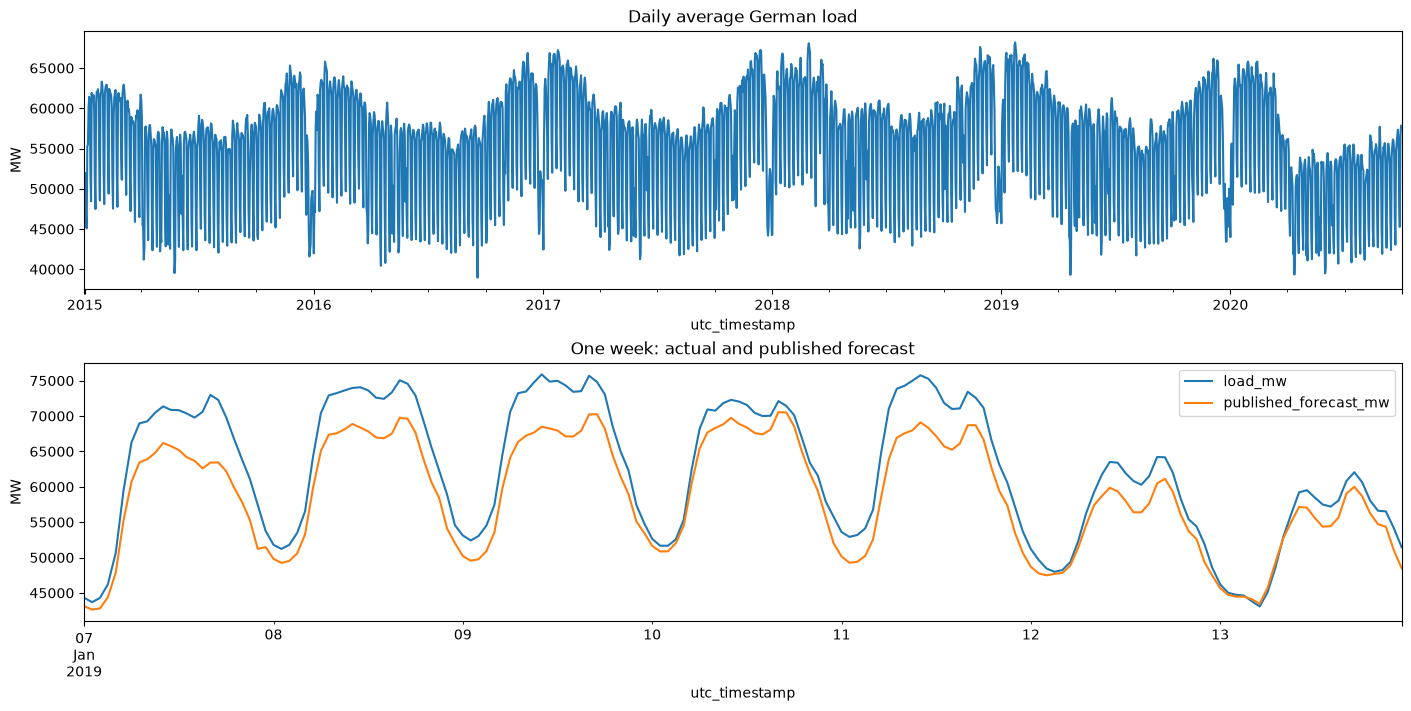

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), constrained_layout=True)
df['load_mw'].resample('D').mean().plot(ax=axes[0], title='Daily average German load')
df.loc['2019-01-07':'2019-01-13', ['load_mw', 'published_forecast_mw']].plot(ax=axes[1], title='One week: actual and published forecast')
axes[0].set_ylabel('MW')
axes[1].set_ylabel('MW')
plt.show()

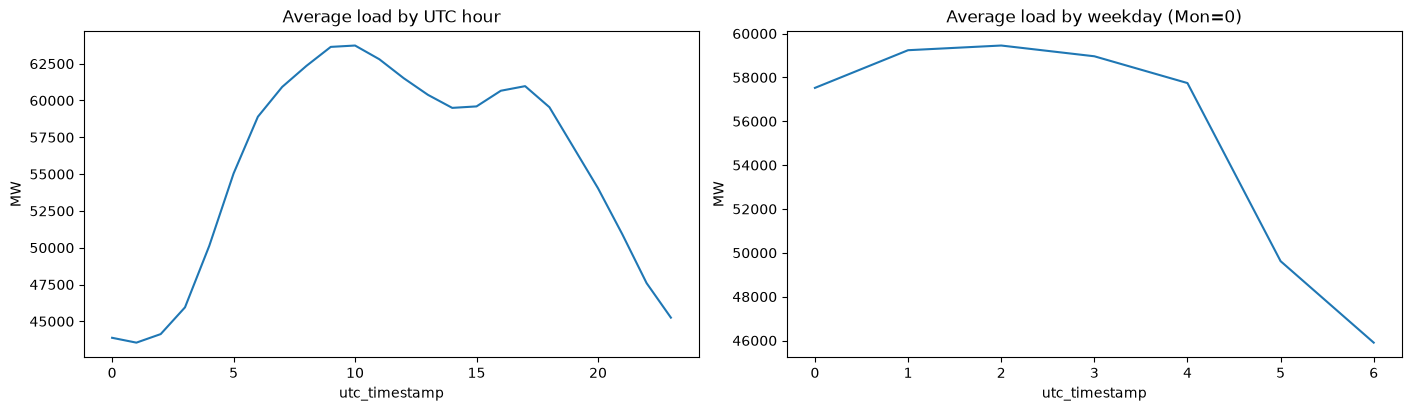

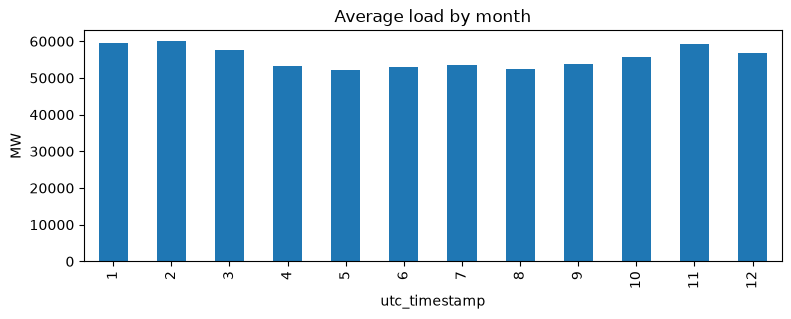

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)
df.groupby(df.index.hour)['load_mw'].mean().plot(ax=axes[0], title='Average load by UTC hour')
df.groupby(df.index.dayofweek)['load_mw'].mean().plot(ax=axes[1], title='Average load by weekday (Mon=0)')
for ax in axes:
    ax.set_ylabel('MW')
plt.show()

monthly = df['load_mw'].groupby(df.index.month).mean()
monthly.plot.bar(figsize=(9, 3), title='Average load by month', ylabel='MW')
plt.show()

Published forecast MAE: 1,685.8 MW
Published forecast bias: -699.4 MW


,count,mae_mw,bias_mw
utc_timestamp,,,
2015,8760,1607.0,-472.0
2016,8784,2028.8,-1558.8
2017,8760,1395.8,-449.0
2018,8736,1577.1,-474.6
2019,8760,1989.2,-1333.5
2020,6576,1458.9,358.0


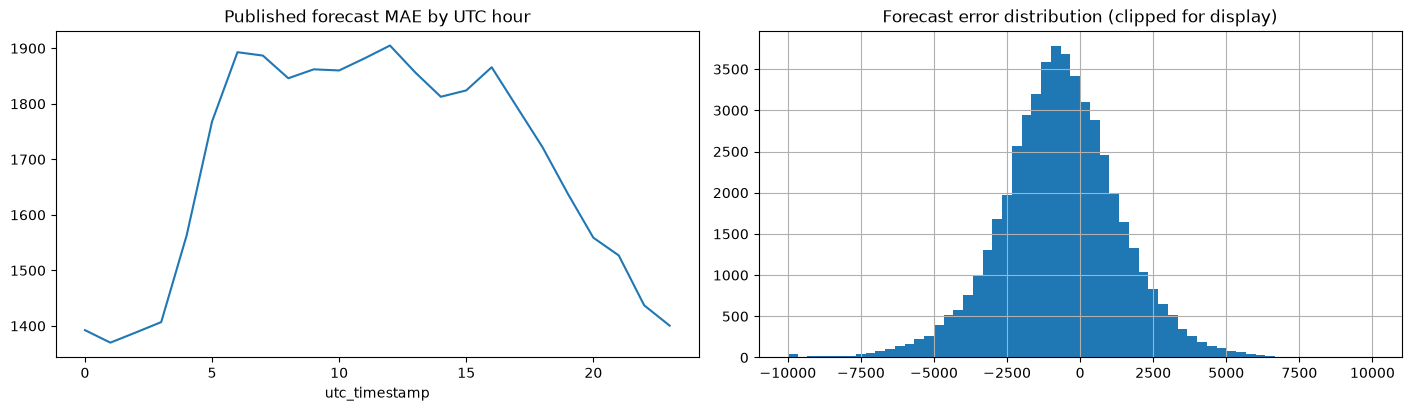

In [5]:
paired = df[['load_mw', 'published_forecast_mw']].dropna().copy()
paired['error_mw'] = paired['published_forecast_mw'] - paired['load_mw']
print(f'Published forecast MAE: {paired.error_mw.abs().mean():,.1f} MW')
print(f'Published forecast bias: {paired.error_mw.mean():,.1f} MW')
display(paired.groupby(paired.index.year)['error_mw'].agg(
    count='count', mae_mw=lambda x: x.abs().mean(), bias_mw='mean'
).round(1))
fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)
paired.groupby(paired.index.hour)['error_mw'].apply(lambda x: x.abs().mean()).plot(ax=axes[0], title='Published forecast MAE by UTC hour')
paired['error_mw'].clip(-10000, 10000).hist(bins=60, ax=axes[1])
axes[1].set_title('Forecast error distribution (clipped for display)')
plt.show()

17:51:17 - cmdstanpy - INFO - Chain [1] start processing
17:51:40 - cmdstanpy - INFO - Chain [1] done processing


published_forecast_mw MAE: 2,728.9 MW
prophet_mw MAE: 5,111.8 MW


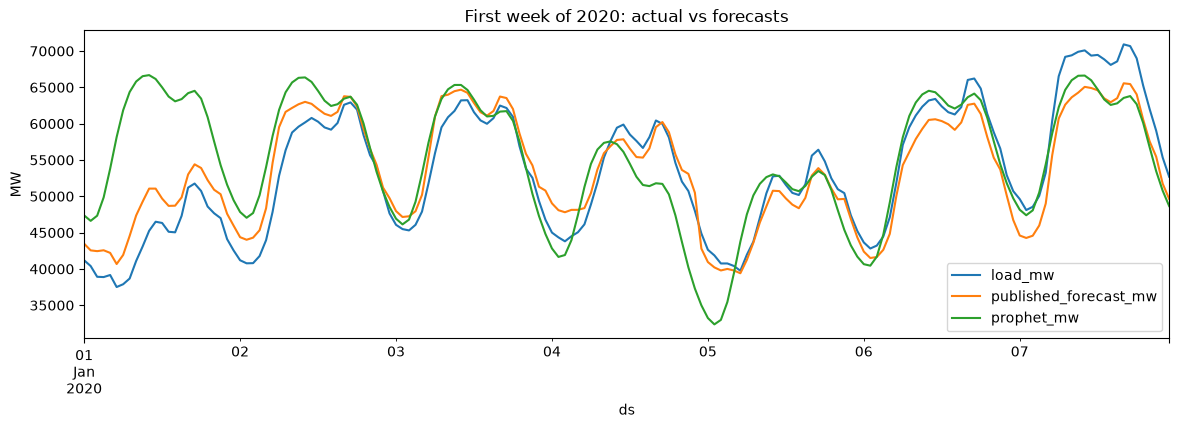

In [6]:
# Optional first Prophet experiment. Install with: python -m pip install prophet
try:
    from prophet import Prophet
except ImportError:
    print('Prophet is not installed. The exploration above is complete; install Prophet to run this cell.')
else:
    train = df.loc['2019-01-01':'2019-12-31', ['load_mw']].dropna().reset_index()
    test = df.loc['2020-01-01':'2020-01-07', ['load_mw', 'published_forecast_mw']].dropna().reset_index()
    # Prophet requires timezone-naive datetimes; these remain UTC timestamps.
    train['ds'] = train['utc_timestamp'].dt.tz_localize(None)
    test['ds'] = test['utc_timestamp'].dt.tz_localize(None)
    model = Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=False)
    model.fit(train[['ds', 'load_mw']].rename(columns={'load_mw': 'y'}))
    result = model.predict(test[['ds']])
    comparison = test[['ds', 'load_mw', 'published_forecast_mw']].copy()
    comparison['prophet_mw'] = result['yhat'].to_numpy()
    for name in ['published_forecast_mw', 'prophet_mw']:
        print(f'{name} MAE: {(comparison[name] - comparison.load_mw).abs().mean():,.1f} MW')
    comparison.set_index('ds')[['load_mw', 'published_forecast_mw', 'prophet_mw']].plot(
        figsize=(14, 4), title='First week of 2020: actual vs forecasts', ylabel='MW'
    )
    plt.show()

In [7]:
## Benchmark: standard ML and neural network

# The full, reproducible implementation is maintained in scripts/benchmark_ml.py.
# This runs the same feature engineering, annual splits, Ridge, gradient boosting,
# and PyTorch neural network used to create the saved metrics and predictions.
from pathlib import Path
import runpy

PROJECT = Path.cwd()
if not (PROJECT / 'scripts' / 'benchmark_ml.py').exists():
    PROJECT = PROJECT.parent
assert (PROJECT / 'scripts' / 'benchmark_ml.py').exists(), 'Open this notebook from the project or notebooks folder.'
runpy.run_path(str(PROJECT / 'scripts' / 'benchmark_ml.py'), run_name='__main__')


Fitting validation_2019: 34,704 training hours
Fitting historical_reference_2020: 43,464 training hours
         period                model  hours  mae_mw  rmse_mw  bias_mw  peak_mae_mw
validation_2019             lag_168h   8760  2558.1   4465.0     51.5       2737.0
validation_2019   selected_policy_mw   8760  2122.1   3194.9     -6.9       2476.9
validation_2019  published_day_ahead   8760  1989.2   2489.4  -1333.5       2893.9
validation_2019             ridge_mw   8760  2080.1   3014.5     21.6       2502.4
validation_2019 gradient_boosting_mw   8760  1404.4   1913.6    146.1       1387.7
validation_2019        neural_net_mw   8760  1459.5   2229.0    197.5       1421.3
      historical_reference_2020             lag_168h   6576  2226.5   3777.6   -196.1       3032.5
      historical_reference_2020   selected_policy_mw   6576  1898.0   2830.8   -163.4       2646.4
      historical_reference_2020  published_day_ahead   6576  1458.9   1891.9    358.0       1740.3
      historical_r

{'__name__': '__main__',
 '__doc__': 'Fair hourly load benchmark: linear, tree, and small neural-network models.',
 '__package__': '',
 '__loader__': None,
 '__spec__': None,
 '__file__': 'c:\\Users\\Hp\\Desktop\\GERMANY_POWER\\scripts\\benchmark_ml.py',
 '__cached__': None,
 '__builtins__': {'__name__': 'builtins',
  '__doc__': "Built-in functions, types, exceptions, and other objects.\n\nThis module provides direct access to all 'built-in'\nidentifiers of Python; for example, builtins.len is\nthe full name for the built-in function len().\n\nThis module is not normally accessed explicitly by most\napplications, but can be useful in modules that provide\nobjects with the same name as a built-in value, but in\nwhich the built-in of that name is also needed.",
  '__package__': '',
  '__loader__': _frozen_importlib.BuiltinImporter,
  '__spec__': ModuleSpec(name='builtins', loader=<class '_frozen_importlib.BuiltinImporter'>, origin='built-in'),
  '__build_class__': <function __build_class

In [8]:
# Show the saved benchmark metrics (MW)
import pandas as pd

metrics = pd.read_csv(PROJECT / 'data' / 'processed' / 'ml_metrics.csv')
display(metrics.round(1))


,period,model,hours,mae_mw,rmse_mw,bias_mw,peak_mae_mw
0,validation_2019,lag_168h,8760,2558.1,4465.0,51.5,2737.0
1,validation_2019,selected_policy_mw,8760,2122.1,3194.9,-6.9,2476.9
2,validation_2019,published_day_ahead,8760,1989.2,2489.4,-1333.5,2893.9
3,validation_2019,ridge_mw,8760,2080.1,3014.5,21.6,2502.4
4,validation_2019,gradient_boosting_mw,8760,1404.4,1913.6,146.1,1387.7
5,validation_2019,neural_net_mw,8760,1459.5,2229.0,197.5,1421.3
6,historical_reference_2020,lag_168h,6576,2226.5,3777.6,-196.1,3032.5
7,historical_reference_2020,selected_policy_mw,6576,1898.0,2830.8,-163.4,2646.4
8,historical_reference_2020,published_day_ahead,6576,1458.9,1891.9,358.0,1740.3
9,historical_reference_2020,ridge_mw,6576,1828.6,2622.2,74.3,2700.3


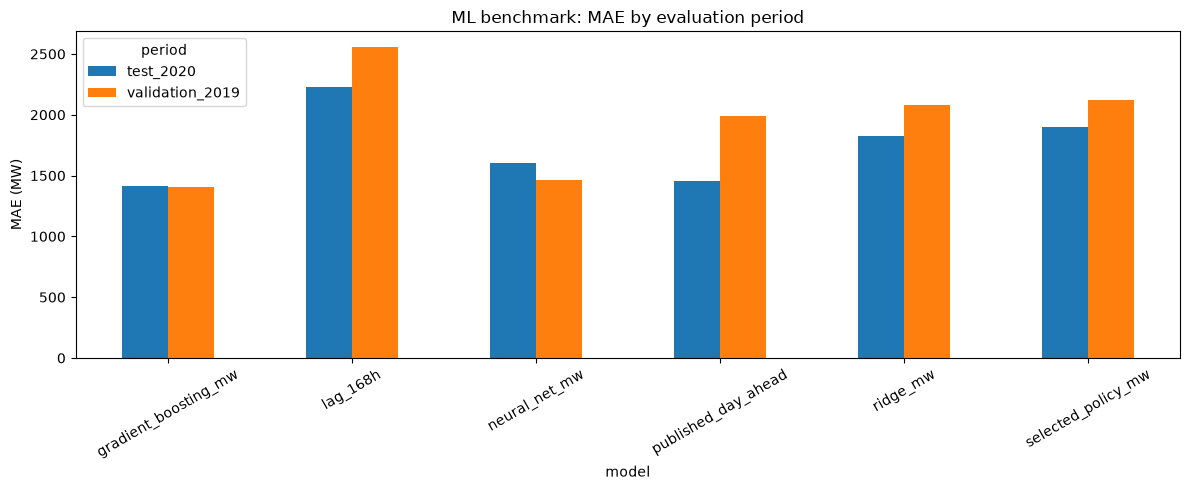

In [9]:
# Compare overall MAE across both periods
mae = metrics.pivot(index='model', columns='period', values='mae_mw')
mae.plot.bar(figsize=(12, 5), ylabel='MAE (MW)', title='ML benchmark: MAE by evaluation period', rot=30)
plt.tight_layout()
plt.show()


In [ ]:
# Interpretation note for the historical reference period
print("The 2020 historical reference was inspected during development; treat it as exploratory, not as an untouched holdout.")
print("The OPSD published-forecast issue/revision vintage is unavailable, so that comparison is provisional.")


In [ ]:
## Stage 4 — Error patterns and load shifts

# Runs scripts/diagnose_rolling_errors.py, which writes the detailed report and CSV slices.
import runpy
PROJECT = Path.cwd()
if not (PROJECT / 'scripts' / 'diagnose_rolling_errors.py').exists():
    PROJECT = PROJECT.parent
runpy.run_path(str(PROJECT / 'scripts' / 'diagnose_rolling_errors.py'), run_name='__main__')


In [ ]:
# Headline errors across validation folds and the already-seen 2020 reference
errors = pd.read_csv(PROJECT / 'data' / 'processed' / 'fold_error_slices.csv')
display(errors.query("slice == 'year'")[['year', 'model', 'hours', 'mae_mw', 'rmse_mw', 'bias_mw']].round(1))


Existing diagnostic results in MW; rerun Step 4 above to regenerate.
year  model                 hours   MAE MW  RMSE MW  bias MW
2017  gradient_boosting      8760  1,422.0   1,974.6   -254.2
2018  gradient_boosting      8736  1,580.1   2,133.4   -226.5
2019  gradient_boosting      8760  1,404.4   1,913.6    146.1
2017  published_reference    8760  1,395.8   1,802.3   -449.0
2018  published_reference    8736  1,577.1   1,999.0   -474.6
2019  published_reference    8760  1,989.2   2,489.4 -1,333.5
2017  weekly_naive           8760  2,445.8   4,415.5     14.2
2018  weekly_naive           8736  2,556.8   4,368.6    -12.6
2019  weekly_naive           8760  2,558.2   4,465.0     51.5
2020  gradient_boosting      6576  1,415.3   1,960.9    319.4
2020  published_reference    6576  1,458.9   1,891.9    358.0
2020  weekly_naive           6576  2,226.5   3,777.6   -196.1


In [ ]:
# Gradient boosting patterns by local season and hour; deciles/holidays are in the CSV report.
errors = pd.read_csv(PROJECT / 'data' / 'processed' / 'fold_error_slices.csv')
season = errors.query("slice == 'season' and model == 'gradient_boosting'")
display(season[['year', 'season', 'hours', 'mae_mw', 'bias_mw']].round(1))
hour = errors.query("slice == 'local_hour' and model == 'gradient_boosting'")
fig, ax = plt.subplots(figsize=(11, 4))
for year, group in hour.groupby('year'):
    ax.plot(group.local_hour, group.mae_mw, marker='o', label=str(year))
ax.set(title='Gradient boosting MAE by German local hour', xlabel='Local hour', ylabel='MAE (MW)')
ax.legend(title='Scored year')
ax.grid(alpha=.25)
plt.show()


In [ ]:
## Stage 5 — Feature availability at issue time

# Checks the lag timestamps against the assumed 12:00 UTC D-1 forecast cutoff.
import runpy
PROJECT = Path.cwd()
if not (PROJECT / 'scripts' / 'audit_feature_availability.py').exists():
    PROJECT = PROJECT.parent
runpy.run_path(str(PROJECT / 'scripts' / 'audit_feature_availability.py'), run_name='__main__')


In [ ]:
# Candidate feature timing and evidence status
from IPython.display import Markdown, display

display(Markdown((PROJECT / 'docs' / 'feature_availability.md').read_text(encoding='utf-8')))


In [ ]:
## Stage 6 — Compare models on the same expanding-window folds

# Refit each learned model once per year on prior years, then save predictions and metrics.
import runpy
PROJECT = Path.cwd()
if not (PROJECT / 'scripts' / 'compare_models_folds.py').exists():
    PROJECT = PROJECT.parent
runpy.run_path(str(PROJECT / 'scripts' / 'compare_models_folds.py'), run_name='__main__')


In [ ]:
# Review results on identical timestamps; pooled metrics do not replace fold-by-fold checks.
model_metrics = pd.read_csv(PROJECT / 'data' / 'processed' / 'expanding_fold_metrics.csv')
paired = pd.read_csv(PROJECT / 'data' / 'processed' / 'paired_model_comparisons.csv')
display(model_metrics.query("year != 'pooled_oof'").sort_values(['year', 'mae_mw']).round(1))
display(model_metrics.query("year == 'pooled_oof'").sort_values('mae_mw').round(1))
display(paired.query("(candidate == 'neural_network' and reference == 'gradient_boosting') or (candidate == 'gradient_boosting' and reference == 'published_reference')").round(1))


Saved pooled out-of-fold scores (MW); run the previous cell to reproduce.
model                  hours    MAE MW  RMSE MW  Bias MW  high-load MAE MW
gradient_boosting       26256   1,468.7   2,009.2   -111.4           1,730.3
neural_network          26256   1,511.4   2,218.5   -312.7           1,812.7
published_reference     26256   1,654.1   2,116.8   -752.6           2,197.8
ridge                   26256   2,042.9   2,947.8   -104.5           2,426.0
same_hour_168h          26256   2,520.2   4,416.6     17.7           2,656.4
prophet                 26256   3,309.2   4,403.4 -1,894.4           3,847.6
same_hour_48h           26256   7,358.5   9,787.2      9.3           7,208.9


In [ ]:
# Fold-to-fold MAE comparison. Every line uses the same timestamps within a year.
fold_metrics = model_metrics.query("year != 'pooled_oof'").copy()
fold_metrics['year'] = fold_metrics.year.astype(int)
mae_by_fold = fold_metrics.pivot(index='year', columns='model', values='mae_mw')
mae_by_fold.plot(marker='o', figsize=(12, 5), ylabel='MAE (MW)', title='Model MAE across expanding-window validation folds')
plt.xticks([2017, 2018, 2019])
plt.grid(alpha=.25)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [ ]:
## Stage 7 — Directional error and operational value

# Computes under/overforecast exposure from the same 2017–2019 fold predictions.
import runpy
PROJECT = Path.cwd()
if not (PROJECT / 'scripts' / 'assess_forecast_value.py').exists():
    PROJECT = PROJECT.parent
runpy.run_path(str(PROJECT / 'scripts' / 'assess_forecast_value.py'), run_name='__main__')


In [ ]:
# Review directional forecast error. MWh-equivalent error volume is not a cost or energy-not-served measure.
value_summary = pd.read_csv(PROJECT / 'data' / 'processed' / 'directional_error_summary.csv')
pooled_value = value_summary.query("period == 'pooled_2017_2019'")
display(pooled_value[['model', 'mae_mw', 'bias_mw', 'underforecast_hours_pct', 'overforecast_hours_pct', 'mean_underforecast_mwh_equiv_per_day', 'mean_overforecast_mwh_equiv_per_day']].round(1))
value_plot = pooled_value.set_index('model')[['mean_underforecast_mwh_equiv_per_day', 'mean_overforecast_mwh_equiv_per_day']]
value_plot.plot.bar(figsize=(10, 4), ylabel='MWh-equivalent error per UTC day', title='Directional load forecast error exposure', rot=25)
plt.tight_layout()
plt.show()
